In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("../dataset/retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 9)


In [6]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*40)

Transaction ID
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  

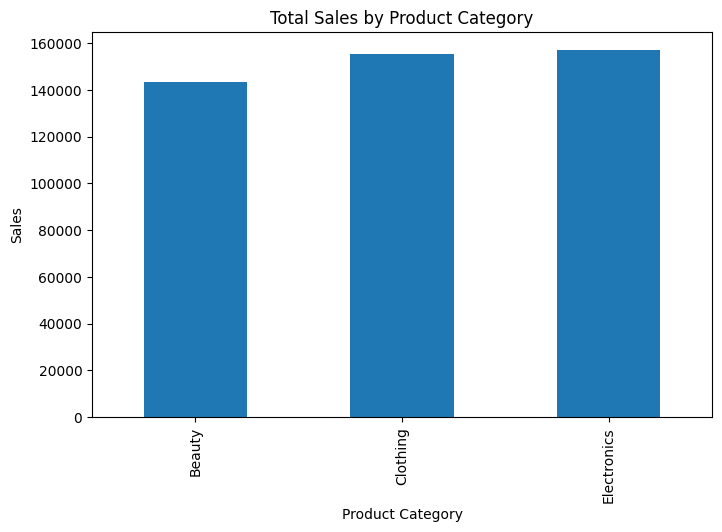

In [20]:
plt.figure(figsize=(8,5))

df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.savefig("../image/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Clothing generated the highest total sales.
- Electronics contributed moderate sales.
- Beauty products had comparatively lower sales.
- The company should focus on promoting high-performing categories while improving sales strategies for low-performing ones.

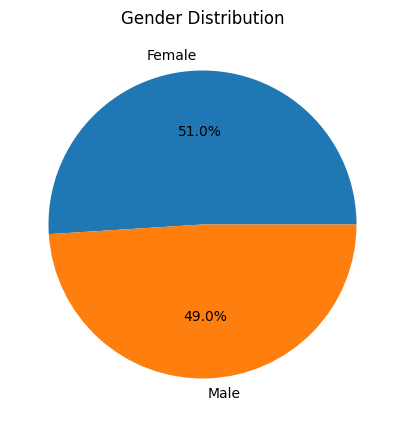

In [22]:
plt.figure(figsize=(5,5))

df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Gender Distribution")
plt.savefig("../image/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Male and Female customers are nearly equally represented.
- This indicates that marketing campaigns should target both demographics.

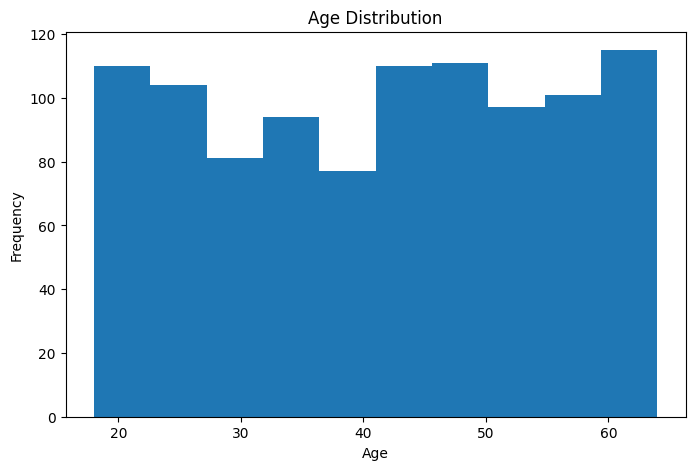

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("../image/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Observation

- Most customers fall between the ages of 25 and 40.
- Young adults appear to be the primary customer segment.

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df["Month"] = df["Date"].dt.month_name()

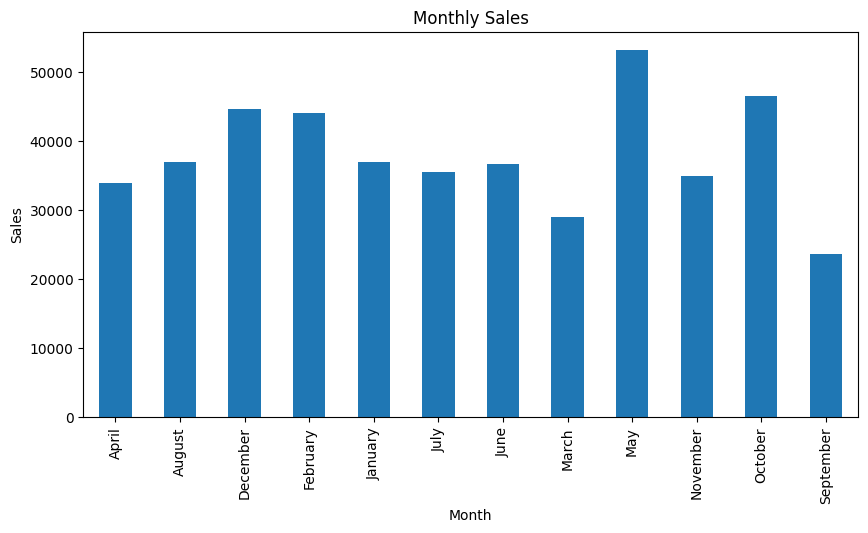

In [24]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Monthly Sales")
plt.ylabel("Sales")

plt.savefig("../image/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Some months show noticeably higher sales than others.
- Seasonal promotions or holidays may have influenced these peaks.

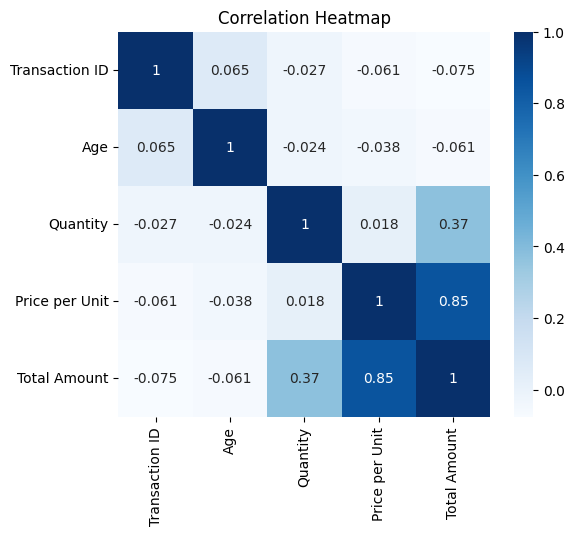

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("../image/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Quantity and Total Amount show a positive correlation.
- Price per Unit also has a significant influence on Total Amount.

# Exploratory Data Analysis (EDA) on Retail Sales Data Analysis

## Objective

## Import Libraries

## Load Dataset

## Dataset Inspection

## Data Cleaning

## Descriptive Statistics

## Exploratory Data Analysis

## Business Insights

## Business Recommendations

## Conclusion

# Business Recommendations

1. Increase inventory for high-selling product categories.
2. Launch promotional offers during low-performing months.
3. Target the 25–40 age group through personalized marketing.
4. Optimize pricing strategies to maximize revenue.
5. Expand marketing efforts in categories with growth potential.

# Conclusion

The exploratory data analysis provided valuable insights into customer purchasing behavior, product performance, and sales trends. These findings can help businesses improve inventory management, optimize marketing strategies, and increase overall profitability.